# Plot the Cosine similarity versus Iteration number for different fluence

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from IPython.display import display
from vector_ptycho.utils import _to_numpy

device = "cuda" if torch.cuda.is_available() else "cpu"

from vector_ptycho.utils import *
from vector_ptycho.plotting_utils import *
from vector_ptycho.Neel_field_sim_utils import *
from vector_ptycho.reconstruction_utils import *




In [2]:
RGB_scale = make_vector_color_map(plot=False)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cdtype = torch.complex64
eps = 1e-8

print(device)

cuda


In [4]:
detector_pixel_size = 6.5e-6 * 4 # Pixel size of the detector (after binning)
wavelength = 1.74e-9 # Wavelength of the X-rays (1.74 nm corresponds to 720 eV)
z = 70e-3 # Sample to detector distance
k = 2 * np.pi / wavelength # Wave number
N = 512 # Number of pixels in the detector
L_detector = N * detector_pixel_size # Detector size

# Define the detector plane coordinates
x_detector = torch.linspace(-L_detector/2, L_detector/2, N, device=device)
y_detector = torch.linspace(-L_detector/2, L_detector/2, N, device=device)
X_detector, Y_detector = torch.meshgrid(x_detector, y_detector, indexing='ij')

# Define the sample plane coordinates
object_pixel_size = (wavelength * z) / (N * detector_pixel_size) # Pixel size in the object/probe plane


L_object = N * object_pixel_size # Object size
x_obj = torch.linspace(-L_object/2, L_object/2, N, device=device)
y_obj = torch.linspace(-L_object/2, L_object/2, N, device=device)
X_obj, Y_obj = torch.meshgrid(x_obj, y_obj, indexing='ij')

print(f"Object pixel size: {object_pixel_size:.2e} m")
print(f"Object size: {L_object:.2e} m")

Object pixel size: 9.15e-09 m
Object size: 4.68e-06 m


In [5]:
H, W = N, N
Lx = N * object_pixel_size
Ly = N * object_pixel_size

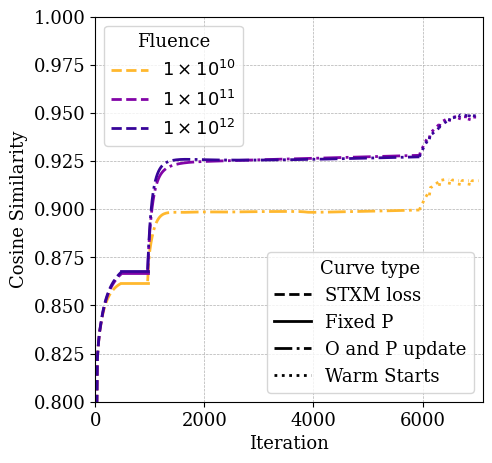

<Figure size 640x480 with 0 Axes>

In [6]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Serif'
mpl.rcParams['font.size'] = 13
# Plasma colour scheme
light_yellow = '#ffb82e'
pinky = '#cf4c73'
light_purple = '#8204a7'
dark_purple = '#370499'

run_files_1e10 = [r'.\fluence_1e10\recon_STXM.pt',
              r'.\fluence_1e10\recon_post_STXM.pt',
                r'.\fluence_1e10\recon_post_STXM_2.pt']

run_files_1e11 = [r'.\fluence_1e11\recon_STXM.pt',
              r'.\fluence_1e11\recon_post_STXM.pt',
                r'.\fluence_1e11\recon_post_STXM_2.pt']

run_files_1e12 = [r'.\fluence_1e12\recon_STXM.pt',
              r'.\fluence_1e12\recon_post_STXM.pt',
                r'.\fluence_1e12\recon_post_STXM_2.pt']


# Add the fine-tuning stages to the run_files_list as well
def add_fine_tuning_stages(run_files_list, fluence_folder, num_stages=2, start=3):
    for i in range(start, num_stages+start):  # Assuming 2 fine-tuning stages after the initial reconstruction
        run_files_list = run_files_list + [f'{fluence_folder}\\recon_post_STXM_{i}.pt']
    return run_files_list

run_files_1e10 = add_fine_tuning_stages(run_files_1e10, r'.\fluence_1e10', num_stages=6, start=3)
run_files_1e11 = add_fine_tuning_stages(run_files_1e11, r'.\fluence_1e11', num_stages=6, start=3)
run_files_1e12 = add_fine_tuning_stages(run_files_1e12, r'.\fluence_1e12', num_stages=6, start=3)

# Each stage of the reconstruction has a different line style.
line_styles = ['--', '-', '-.'] + [':'] * 10  # Dashed for initial, solid for post-STXM, dash-dot for first fine-tuning, then solid for the rest
colours = [light_yellow, light_purple, dark_purple]

fig, ax = plt.subplots(figsize=(5, 5))

plot_checkpoint_history(
    run_files_1e10,
    label=r"$1\times 10^{10}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[0]
)
plot_checkpoint_history(
    run_files_1e11,
    label=r"$1\times 10^{11}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[1]
)
plot_checkpoint_history(
    run_files_1e12,
    label=r"$1\times 10^{12}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[2]
)

# Colour legend (generated automatically from plotted lines)
colour_legend = ax.legend(title="Fluence", loc="upper left")

# Linestyle legend
style_labels = ["STXM loss", "Fixed P", "O and P update", "Warm Starts"]

style_handles = [
    Line2D([0], [0], color='black', linestyle=ls, linewidth=2, label=lbl)
    for ls, lbl in zip(line_styles[0:4], style_labels[0:4])
]

style_legend = ax.legend(
    handles=style_handles,
    title="Curve type",
    loc="lower right"
)

# Add the first legend back after creating the second
ax.add_artist(colour_legend)
# Add a horizontal dashed line at y=1.0 to indicate perfect cosine similarity
#ax.plot([0, 3000], [1.0, 1.0], color='black', linestyle=':', linewidth=1)
ax.set_ylim(0.8, 1.00)
#ax.set_ylim(0.9, 0.95)
ax.set_xlim(0, 7100)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.savefig("ptycho_recon_progress_1e10_1e11_1e12.svg", dpi=300)

C:\Users\godfrey\Documents\Ptycho development GPU\vector-ptycho\src\vector_ptycho\plotting_utils.py:518: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


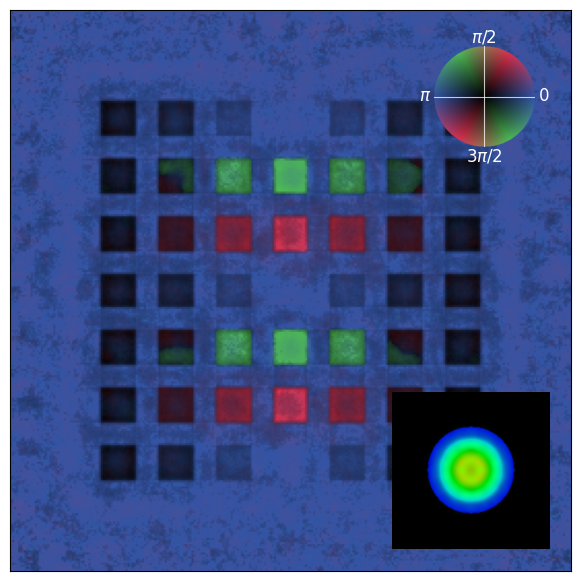

(<Figure size 600x600 with 3 Axes>, <Axes: >)

In [7]:
ckpt = torch.load(r'.\fluence_1e12\recon_post_STXM_10.pt')
l = ckpt['l']

crop_size = 120  # Number of pixels to crop from each edge
X_obj_cropped = X_obj[crop_size:-crop_size, crop_size:-crop_size]
Y_obj_cropped = Y_obj[crop_size:-crop_size, crop_size:-crop_size]
recon_l_cropped = l[:, crop_size:-crop_size, crop_size:-crop_size]
theta, phi = cartesian_to_spherical(recon_l_cropped.detach())
plot_theta_phi_maps(theta, phi, Lx, Ly,
                       positions=None,
                       theta_cmap='magma',
                       phi_cmap=RGB_scale,
                       dx=0.0, dy=0.0,
                       show_positions=True,
                       label_positions=False,
                       label_axes=False,
                       probe_amplitude=ckpt['probe_amplitude'],
                       show_probe_inset=True,
                       probe_inset_crop=200,
                       title_on=False)

# Cross-sections through an edge

C:\Users\godfrey\AppData\Local\Temp\ipykernel_28012\3363924841.py:110: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  data_phi = np.mod(data_phi, np.pi)
C:\Users\godfrey\AppData\Local\Temp\ipykernel_28012\3363924841.py:111: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  data_theta = np.abs(np.cos(data_theta))


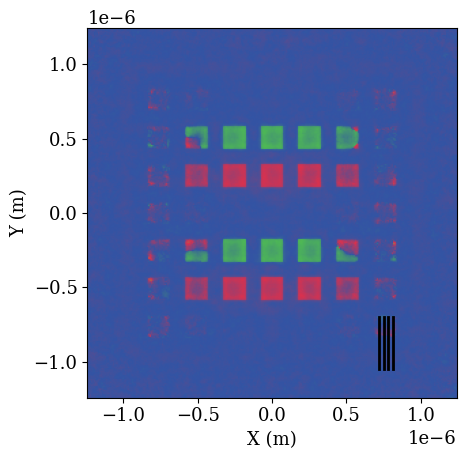

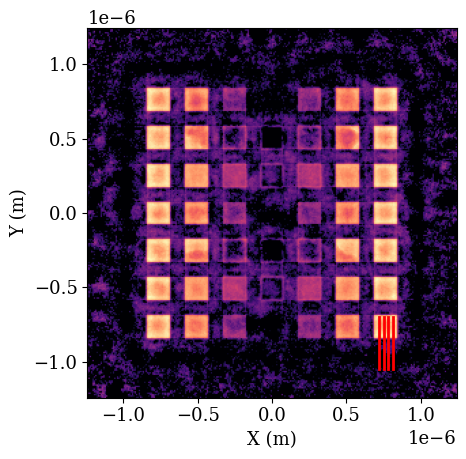

Fitted parameters for data_theta: [-3.99629086e-01  2.02700054e-07 -7.66623012e-09  4.57323714e-01]


C:\Users\godfrey\AppData\Local\Temp\ipykernel_28012\3363924841.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _data = np.array(data)


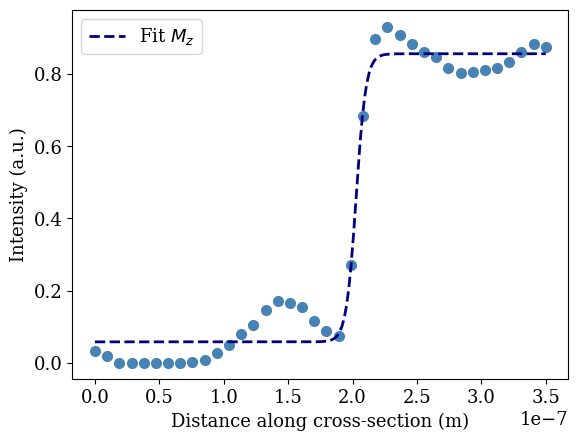

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit

def extract_cross_section(data, X, Y, start, end, n_points=None):
    """Extract a 1-D cross-section from *data* between two real-world coordinates.

    The line between *start* and *end* is sampled using bilinear interpolation
    on the underlying grid. The x-axis of the returned profile is real
    distance along the line (same units as X, Y).

    This implementation is robust to whether `X, Y` were produced with
    ``meshgrid(indexing='ij')`` or the default ``'xy'``: it derives the
    1-D axes from the unique coordinate values and ensures the data array
    has the expected axis order for ``RegularGridInterpolator``.
    """
    x0, y0 = float(start[0]), float(start[1])
    x1, y1 = float(end[0]),   float(end[1])

    length = np.hypot(x1 - x0, y1 - y0)
    if length == 0:
        raise ValueError("start and end coordinates are identical.")
    n_points = int(length/object_pixel_size)

    t = np.linspace(0.0, 1.0, n_points)
    line_x = x0 + t * (x1 - x0)
    line_y = y0 + t * (y1 - y0)
    distance = t * length

    # Derive 1-D coordinate axes from the 2-D grids (works for 'ij' or 'xy')
    x_axis = np.unique(X)
    y_axis = np.unique(Y)

    # Ensure ascending order
    if x_axis[0] > x_axis[-1]:
        x_axis = x_axis[::-1]
    if y_axis[0] > y_axis[-1]:
        y_axis = y_axis[::-1]

    # Prepare data so that its shape matches (len(y_axis), len(x_axis))
    _data = np.array(data)
    ny, nx = y_axis.size, x_axis.size
    if _data.shape == (ny, nx):
        pass
    elif _data.shape == (nx, ny):
        _data = _data.T
    else:
        # Try to be helpful if the incoming arrays are transposed from
        # the expected orientation; otherwise raise a clear error.
        if _data.shape[0] == nx and _data.shape[1] == ny:
            _data = _data.T
        else:
            raise ValueError(
                f"data shape {_data.shape} incompatible with derived axes sizes {(ny, nx)}"
            )

    interp = RegularGridInterpolator(
        (y_axis, x_axis), _data, method="linear", bounds_error=False, fill_value=np.nan
    )

    query_pts = np.column_stack([line_y, line_x])
    profile = interp(query_pts)

    return distance, profile, line_x, line_y


def _tanh_model(x, A, x0, w, B):
    """
    Generalised tanh:
 
        f(x) = A * tanh((x - x0) / w) + B
 
    Parameters
    ----------
    A   : amplitude  (half the total swing from trough to peak)
    x0  : inflection point (centre of the transition)
    w   : width parameter  (smaller → steeper transition)
    B   : vertical offset  (midpoint value)
    """
    return A * np.tanh((x - x0) / w) + B

# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------



X, Y = X_obj_cropped.cpu().numpy(), Y_obj_cropped.cpu().numpy()


# Good coordinates for phi resolution test
start = [(-0.02e-6, 0.05e-6), (0.01e-6, 0.05e-6), (-0.05e-6, 0.05e-6), (0.03e-6, 0.05e-6)]
end   = [(-0.02e-6, 0.3e-6), (0.01e-6, 0.3e-6), (-0.05e-6, 0.3e-6), (0.03e-6, 0.3e-6)]
fit_theta = False
fit_phi = True



# Good coordinates for theta resolution test
start = [(0.72e-6, -1.05e-6), (0.75e-6, -1.05e-6), (0.78e-6, -1.05e-6), (0.81e-6, -1.05e-6)]
end   = [(0.72e-6, -0.70e-6), (0.75e-6, -0.70e-6), (0.78e-6, -0.70e-6), (0.81e-6, -0.70e-6)]
fit_theta = True
fit_phi = False


data_theta = theta
data_phi = phi

data_phi = np.mod(data_phi, np.pi)
data_theta = np.abs(np.cos(data_theta))

plt.imshow(data_phi, extent=(X.min(), X.max(), Y.min(), Y.max()), origin='lower', cmap=RGB_scale, vmin=0, vmax=np.pi)
for i in range(0, len(start)):
    plt.plot([start[i][0], end[i][0]], [start[i][1], end[i][1]], 'black', lw=2)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()

plt.imshow(data_theta, extent=(X.min(), X.max(), Y.min(), Y.max()), origin='lower', cmap='magma')
for i in range(0, len(start)):
    plt.plot([start[i][0], end[i][0]], [start[i][1], end[i][1]], 'r-', lw=2)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()

profiles_theta = []
profiles_phi = []

for i in range(0, len(start)):
    distance_theta, profile_theta, line_x, line_y = extract_cross_section(data_theta, X, Y, start=start[i], end=end[i], n_points=None)
    distance_phi, profile_phi, line_x, line_y = extract_cross_section(data_phi, X, Y, start=start[i], end=end[i], n_points=None)

    profiles_theta.append(profile_theta)
    profiles_phi.append(profile_phi)

profiles_theta = np.array(profiles_theta)
profiles_phi = np.array(profiles_phi)

profile_theta = np.mean(profiles_theta, axis=0)
profile_phi = np.mean(profiles_phi, axis=0)

distance_theta_interpolated = np.linspace(distance_theta.min(), distance_theta.max(), 200)
distance_phi_interpolated = np.linspace(distance_phi.min(), distance_phi.max(), 200)
if fit_theta:
    popt_theta, pcov_theta = curve_fit(
    _tanh_model, distance_theta, profile_theta, p0=[1.0, distance_theta[len(distance_theta) // 2], 0.5e-6, 1.0]
    )
    print("Fitted parameters for data_theta:", popt_theta)

if fit_phi:
    popt_phi, pcov_phi = curve_fit(
    _tanh_model, distance_phi, profile_phi, p0=[1.0, distance_phi[len(distance_phi) // 2], 0.5e-6, 1.0]
    )
    print("Fitted parameters for data_phi:", popt_phi)

if fit_theta:
    plt.scatter(distance_theta, profile_theta, lw=2, color="steelblue")
    plt.plot(distance_theta_interpolated, _tanh_model(distance_theta_interpolated, *popt_theta), lw=2, color="navy", ls="--", label=r"Fit $M_z$")
if fit_phi:
    plt.scatter(distance_phi, profile_phi, lw=2, color="lightcoral")
    plt.plot(distance_phi_interpolated, _tanh_model(distance_phi_interpolated, *popt_phi), lw=2, color="darkred", ls="--", label=r"Fit $\phi$")

#plt.xlim(1.0e-7, 1.5e-7)
plt.legend()
plt.xlabel("Distance along cross-section (m)")
plt.ylabel("Intensity (a.u.)")
plt.show()



## Make a function that loads in the checkpoint files from a list, then performs the cross-section for M_z and phi and plots it. Then plots those cross-sections on subplot 1 and 2. For the 3rd subplot, I would like the w-fitting parameter plotted as a function of fluence 1e10, 1e11, 1e12. The start and end coordinates are different for whether I am doing a phi cross-section or M_z cross-section.

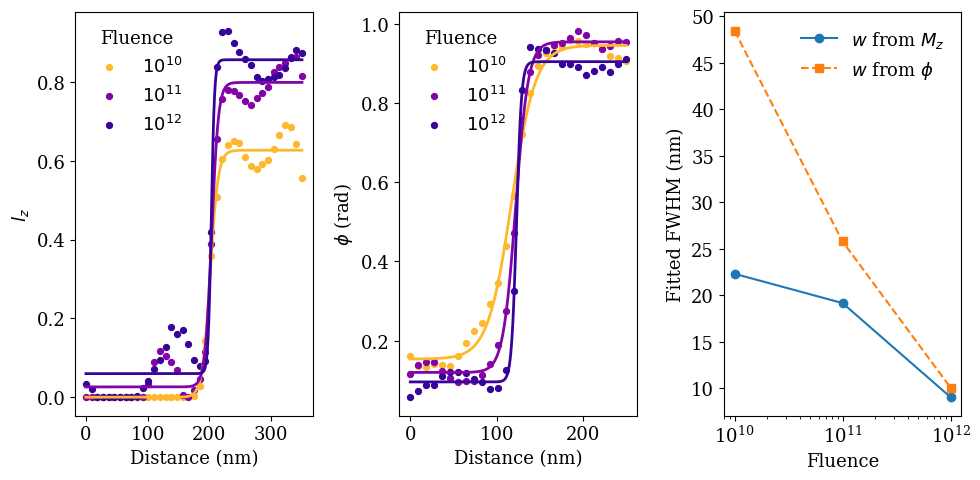

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit


def fluence_label(fluence):
    """
    Convert e.g.
        1e10 -> r"$1\\times10^{10}$"
        3e11 -> r"$3\\times10^{11}$"
    """
    exponent = int(np.floor(np.log10(fluence)))
    coefficient = fluence / 10**exponent

    if np.isclose(coefficient, 1):
        return rf"$10^{{{exponent}}}$"
    else:
        return rf"${coefficient:g}\times10^{{{exponent}}}$"

def extract_cross_section(data, X, Y, start, end, object_pixel_size, n_points=None):
    """
    Extract a 1-D cross-section from data between two real-world coordinates.
    Returns distance along line, profile values, and line coordinates.
    """
    x0, y0 = float(start[0]), float(start[1])
    x1, y1 = float(end[0]), float(end[1])

    length = np.hypot(x1 - x0, y1 - y0)
    if length == 0:
        raise ValueError("start and end coordinates are identical.")

    if n_points is None:
        n_points = max(2, int(np.ceil(length / object_pixel_size)))

    t = np.linspace(0.0, 1.0, n_points)
    line_x = x0 + t * (x1 - x0)
    line_y = y0 + t * (y1 - y0)
    distance = t * length

    x_axis = np.unique(X)
    y_axis = np.unique(Y)

    if x_axis[0] > x_axis[-1]:
        x_axis = x_axis[::-1]
    if y_axis[0] > y_axis[-1]:
        y_axis = y_axis[::-1]

    _data = np.array(data)
    ny, nx = y_axis.size, x_axis.size

    if _data.shape == (ny, nx):
        pass
    elif _data.shape == (nx, ny):
        _data = _data.T
    else:
        raise ValueError(
            f"data shape {_data.shape} incompatible with derived axes sizes {(ny, nx)}"
        )

    interp = RegularGridInterpolator(
        (y_axis, x_axis),
        _data,
        method="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    query_pts = np.column_stack([line_y, line_x])
    profile = interp(query_pts)

    return distance, profile, line_x, line_y


def _tanh_model(x, A, x0, w, B):
    return A * np.tanh((x - x0) / w) + B


def average_cross_section(data, X, Y, starts, ends, object_pixel_size):
    """
    Extract multiple cross-sections and average them.
    Assumes each start/end pair has the same line length.
    """
    profiles = []
    distance_ref = None

    for s, e in zip(starts, ends):
        distance, profile, _, _ = extract_cross_section(
            data, X, Y, start=s, end=e, object_pixel_size=object_pixel_size
        )

        if distance_ref is None:
            distance_ref = distance
        elif len(distance) != len(distance_ref):
            # Resample to the first line's grid if needed
            finite = np.isfinite(profile)
            profile = np.interp(distance_ref, distance[finite], profile[finite])

        profiles.append(profile)

    profiles = np.array(profiles)
    mean_profile = np.nanmean(profiles, axis=0)

    return distance_ref, mean_profile


def fit_profile(distance, profile):
    """
    Fit the tanh model to a profile and return fit parameters.
    """
    mask = np.isfinite(distance) & np.isfinite(profile)
    distance_fit = distance[mask]
    profile_fit = profile[mask]

    if len(distance_fit) < 5:
        raise ValueError("Not enough valid points to fit the profile.")

    p0 = [
        1.0,
        distance_fit[len(distance_fit) // 2],
        0.5e-6,
        np.mean(profile_fit),
    ]

    popt, pcov = curve_fit(_tanh_model, distance_fit, profile_fit, p0=p0)
    return popt, pcov


def process_checkpoint(
    ckpt_path,
    X_obj,
    Y_obj,
    crop_size,
    object_pixel_size,
    mz_starts,
    mz_ends,
    phi_starts,
    phi_ends,
):
    """
    Load one checkpoint, compute Mz and phi, extract averaged cross-sections,
    and fit the tanh model.

    Returns cross-section data with nm units
    """
    ckpt = torch.load(ckpt_path, map_location="cpu")
    l = ckpt["l"]

    X_obj_cropped = X_obj[crop_size:-crop_size, crop_size:-crop_size]
    Y_obj_cropped = Y_obj[crop_size:-crop_size, crop_size:-crop_size]
    recon_l_cropped = l[:, crop_size:-crop_size, crop_size:-crop_size]

    theta, phi = cartesian_to_spherical(recon_l_cropped.detach())

    theta = theta.detach().cpu().numpy()
    phi = phi.detach().cpu().numpy()

    # Your original definitions
    data_mz = np.abs(np.cos(theta))
    data_phi = np.mod(phi, np.pi)

    X = X_obj_cropped.cpu().numpy()
    Y = Y_obj_cropped.cpu().numpy()

    dist_mz, prof_mz = average_cross_section(
        data_mz, X, Y, mz_starts, mz_ends, object_pixel_size
    )
    dist_phi, prof_phi = average_cross_section(
        data_phi, X, Y, phi_starts, phi_ends, object_pixel_size
    )

    popt_mz, pcov_mz = fit_profile(dist_mz, prof_mz)
    popt_phi, pcov_phi = fit_profile(dist_phi, prof_phi)

    return {
        "ckpt_path": ckpt_path,
        "dist_mz": dist_mz,
        "prof_mz": prof_mz,
        "popt_mz": popt_mz,
        "pcov_mz": pcov_mz,
        "dist_phi": dist_phi,
        "prof_phi": prof_phi,
        "popt_phi": popt_phi,
        "pcov_phi": pcov_phi,
    }


# -------------------------------------------------------------------------
# Example inputs
# -------------------------------------------------------------------------

crop_size = 120

# Same fluence ordering as your desired third subplot
datasets = [
    {"fluence": 1e10, "ckpt": r".\fluence_1e10\recon_post_STXM_10.pt"},
    {"fluence": 1e11, "ckpt": r".\fluence_1e11\recon_post_STXM_10.pt"},
    {"fluence": 1e12, "ckpt": r".\fluence_1e12\recon_post_STXM_10.pt"},
]

# Cross-section coordinates for Mz
mz_starts = [
    (0.72e-6, -1.05e-6),
    (0.75e-6, -1.05e-6),
    (0.78e-6, -1.05e-6),
    (0.81e-6, -1.05e-6),
]
mz_ends = [
    (0.72e-6, -0.70e-6),
    (0.75e-6, -0.70e-6),
    (0.78e-6, -0.70e-6),
    (0.81e-6, -0.70e-6),
]

# Cross-section coordinates for phi
phi_starts = [
    (-0.02e-6, 0.05e-6),
    (0.01e-6, 0.05e-6),
    (-0.05e-6, 0.05e-6),
    (0.03e-6, 0.05e-6),
]
phi_ends = [
    (-0.02e-6, 0.30e-6),
    (0.01e-6, 0.30e-6),
    (-0.05e-6, 0.30e-6),
    (0.03e-6, 0.30e-6),
]

# -------------------------------------------------------------------------
# Run all datasets
# -------------------------------------------------------------------------

results = []
for ds in datasets:
    res = process_checkpoint(
        ds["ckpt"],
        X_obj=X_obj,
        Y_obj=Y_obj,
        crop_size=crop_size,
        object_pixel_size=object_pixel_size, # Already calculated above
        mz_starts=mz_starts,
        mz_ends=mz_ends,
        phi_starts=phi_starts,
        phi_ends=phi_ends,
    )
    res["fluence"] = ds["fluence"]
    results.append(res)

# Sort by fluence just in case
results = sorted(results, key=lambda d: d["fluence"])

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

colors = [light_yellow, light_purple, dark_purple]#plt.cm.viridis(np.linspace(0, 1, len(results)))

for i, res in enumerate(results):
    fluence = res["fluence"]
    color = colors[i]

    # Mz subplot
    ax[0].scatter(res["dist_mz"]*1e9, res["prof_mz"], s=18, color=color, label=fluence_label(fluence))
    xfit = np.linspace(np.nanmin(res["dist_mz"]), np.nanmax(res["dist_mz"]), 300)
    ax[0].plot(xfit*1e9, _tanh_model(xfit, *res["popt_mz"]), color=color, lw=2)

    # phi subplot
    ax[1].scatter(res["dist_phi"]*1e9, res["prof_phi"], s=18, color=color, label=fluence_label(fluence))
    xfit = np.linspace(np.nanmin(res["dist_phi"]), np.nanmax(res["dist_phi"]), 300)
    ax[1].plot(xfit*1e9, _tanh_model(xfit, *res["popt_phi"]), color=color, lw=2)

# Third subplot: w vs fluence
fluences = np.array([r["fluence"] for r in results], dtype=float)
w_mz = np.array([r["popt_mz"][2] for r in results], dtype=float)
w_phi = np.array([r["popt_phi"][2] for r in results], dtype=float)

ax[2].plot(fluences, w_mz*1e9*1.763, "o-", label=r"$w$ from $M_z$")
ax[2].plot(fluences, w_phi*1e9*1.763, "s--", label=r"$w$ from $\phi$")
ax[2].set_xscale("log")

#ax[0].set_title(r"$M_z$ cross-sections")
#ax[1].set_title(r"$\phi$ cross-sections")
#ax[2].set_title(r"Fitted $w$ vs fluence")

ax[0].set_xlabel("Distance (nm)")
ax[1].set_xlabel("Distance (nm)")
ax[2].set_xlabel("Fluence")
ax[0].set_ylabel(r"$l_z$")
ax[1].set_ylabel(r"$\phi$ (rad)")
ax[2].set_ylabel(r"Fitted FWHM (nm)")

ax[0].legend(title="Fluence",frameon=False)
ax[1].legend(title="Fluence",frameon=False)
ax[2].legend(frameon=False)

plt.tight_layout()
plt.savefig("tanh_resolution_tests_bare.svg", dpi=300)
plt.show()